In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
save=True

# var_all=['u','v','w','b']
# ylabels=[r"$\langle$E$_{ux} \rangle_y$ [m$^{3}$ s$^{-2}]$",r"$\langle$E$_{vx} \rangle_y$ [m$^{3}$ s$^{-2}]$",
#          r"$\langle$E$_{wx} \rangle_y$ [m$^{3}$ s$^{-2}]$",r"$\langle$E$_{bx} \rangle_y$ [m$^{3}$ s$^{-2}]$"]
var_all=['u','w']
ylabels=[r"$\langle$E$_{ux} \rangle_y$ [m$^{3}$ s$^{-2}]$",r"$\langle$E$_{wx} \rangle_y$ [m$^{3}$ s$^{-2}]$"]

Re_all=['Re2700/']

timesteps_all=[[0,2,4,6,8,10,11,12]]

hgts_c=[ 10.03]
hgts_h=[ 9.88]

outdir=""

<xarray.Dataset>
Dimensions:  (time: 13, z: 64, y: 32, xh: 32)
Coordinates:
  * time     (time) float64 0.0 1.8e+03 3.6e+03 ... 1.8e+04 1.98e+04 2.16e+04
  * z        (z) float64 0.1412 0.4236 0.706 0.9885 ... 17.09 17.37 17.65 17.93
  * y        (y) float64 0.4279 1.284 2.14 2.995 ... 24.39 25.25 26.1 26.96
  * xh       (xh) float64 0.0 0.8558 1.712 2.567 ... 23.96 24.82 25.67 26.53
Data variables:
    u        (time, z, y, xh) float64 ...
Plot spectra plot for time 0.0 at height [10.02589025]
Plot spectra plot for time 3600.0 at height [10.02589025]
Plot spectra plot for time 7200.0 at height [10.02589025]
Plot spectra plot for time 10800.0 at height [10.02589025]
Plot spectra plot for time 14400.0 at height [10.02589025]
Plot spectra plot for time 18000.0 at height [10.02589025]
Plot spectra plot for time 19800.0 at height [10.02589025]
Plot spectra plot for time 21600.0 at height [10.02589025]
<xarray.Dataset>
Dimensions:  (time: 13, y: 32, x: 32, zh: 64)
Coordinates:
  * time     

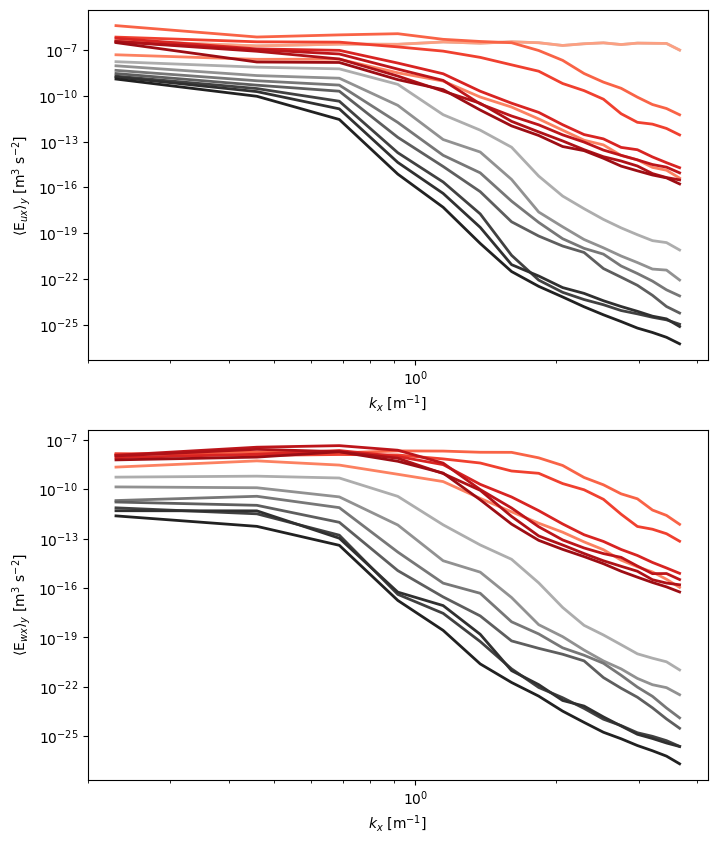

In [3]:
try:
    del fig,axs
    fig,axs=plt.subplots(len(var_all),1,figsize=(8,10))
except:
    fig,axs=plt.subplots(len(var_all),1,figsize=(8,10))
paths=['../cases/SBL_Smag/','../cases/SBL_DNN/']
pathLabels=['Smagorinsky','C4DNN ']
cmaps = ['Greys','Reds','Blues']

markers = ['.','x','*']
for iRe in range(len(Re_all)):
    timesteps=timesteps_all[iRe]
    dTime=timesteps[-1]-timesteps[0]
    pad = .2
    norm = matplotlib.colors.Normalize(vmin=timesteps[0]-3*pad*dTime, vmax=timesteps[-1]+pad*dTime) 
        
    for iLES in range(len(paths)):
        path=paths[iLES]
        cmap=matplotlib.colormaps[cmaps[iLES]]
        dTime=timesteps[-1]-timesteps[0]
        
        # color=colors[iLES]
        #marker=markers[iLES]
        for ivar in range(len(var_all)):

            var=var_all[ivar]
            ds = xr.open_dataset(path+var+'.nc')#'_longTime.nc')
            print(ds)

            times = ds['time']
            Re=Re_all[iRe]
            timesteps=timesteps_all[iRe]
            nt=len(timesteps)

            for it,timestep in enumerate(timesteps):
                color=cmap(norm(timestep))
                
                try:
                    w=ds[var][timestep].values
                except:
                    break
                    
                try:
                  x=ds['xh'].values
                except:
                  x=ds['x'].values
                nx=len(x)
                dx=np.mean(np.diff(x))

                try:
                  y=ds['yh'].values
                except:
                  y=ds['y'].values
                ny=len(y)
    
                try:
                  z=ds['zh'].values
                  hgts=hgts_h
                except:
                  z=ds['z'].values
                  hgts=hgts_c

                
                for ihgt,hgt in enumerate(hgts):
                    hgt=hgts[ihgt]
                    # color=colors[ihgt]
                    k=[(np.abs(z - hgt)).argmin()]
        
                    kxy = 2*np.pi*np.fft.rfftfreq(nx,d=dx)
                    dk=kxy[1] # should be smallest wavenumber 2pi/(length_fline*dx)
                    lenf=len(kxy)# length_fline/2+1
                    sp = np.empty([ny,lenf])
                    #sp = np.empty([nF,avgt,length_yline,lenf])
                    #sP = np.empty([nF,lenf])
                    print('Plot spectra plot for time '+str(times[timestep].values)+' at height '+str(z[k]))
                    #Can make use of below loop if we want to loop through files but b/c the NBL is developping probably shouldn't
                    #  for F in range(nF): # File index
                    #    for i in range(avgt): # Time index
                    #      for ix in range(length_fline): # x (lon) index
                    #        for iy in range(length_yline): # y (lat) index
                    #          Wall[F,i,ix,iy]=fsall[F][nstart+i].variables['W'][nsall[F][nstart+i]][k][(Y1+iy),(X1+ix)]
                               # Wdiag = np.array([fsall[F][nstart+i].variables['W'][nsall[F][nstart+i]][k][Y1-count,X1] for count in range(length_fline)])
                                #normalize spectra values
                    #    for i in range(avgt):
                    #      for iy in range(length_yline):
        
                    #Different detrending options
                    #N = np.linspace(0,Wall[F,i,0,iy]-Wall[F,i,-1,iy],Wall[F,i,:,iy].shape[0])
                    #N = -np.mean(Wall[F,i,:,iy])
                    N=0 # detrending not necessary b/c periodic BCs
                    for j in range(ny):
                        sp_tmp = np.fft.rfft(w[k,j,:]+N)
                        # sp_tmp = np.fft.rfft(w[k,:,j]+N)
                        sp[j,:] = (np.power(sp_tmp.real,2) + np.power(sp_tmp.imag,2))*dx/2.0/np.pi/nx #missing factor of two from Durran paper neccesary for the parseval's thereom to work
                        sp[j,-1] = sp[j,-1]/2.0 #Nyquist frequency (last entry by order of reqdiag) is unique for even pts FFT, so has twice the power
                        sp[j,0] = sp[j,0]/2.0 # Calculating the 0 wavenumber, won't be plotted on a log log but just to check the assumption of zero power at zero wavenumber for different detrending methods
                        #Confirming calcs throuch Parseval's theorem
                        # wsqr=np.sum(np.power(w[k,j],2))/nx/2.0
                        # wsqr_fft=np.sum(sp[j])*dk
                        # print(wsqr-wsqr_fft)
        
                    sP = np.mean(sp,axis=0)
                    power = abs(sP)

                    # legEnd=''
                    # if path==paths[-1]  or path==paths[1]:
                    legEnd='    '+str(0.5*(timestep))+' h'
                    
                    axs[ivar].loglog(kxy[1:],power[1:],color=color,linewidth=2,label=pathLabels[iLES]+legEnd)

            axs[ivar].set_xlabel(r"$k_x$ [m$^{-1}$]")#,fontsize=fs)
            axs[ivar].set_ylabel(ylabels[ivar])#,fontsize=fs)


<xarray.Dataset>
Dimensions:  (xh: 960, y: 960, z: 4992, time: 1)
Coordinates:
  * xh       (xh) float32 0.0 0.02853 0.05705 0.08558 ... 27.27 27.3 27.33 27.36
  * y        (y) float32 0.01426 0.04279 0.07132 0.09985 ... 27.31 27.34 27.37
  * z        (z) float32 0.00181 0.005431 0.009052 0.01267 ... 18.07 18.07 18.07
  * time     (time) int32 -2147483647
Data variables:
    u        (time, z, y, xh) float32 ...
Plot spectra plot for time 1386000 at height 10.031322
<xarray.Dataset>
Dimensions:  (x: 960, y: 960, zh: 4992, time: 1)
Coordinates:
  * x        (x) float32 0.01426 0.04279 0.07132 0.09985 ... 27.31 27.34 27.37
  * y        (y) float32 0.01426 0.04279 0.07132 0.09985 ... 27.31 27.34 27.37
  * zh       (zh) float32 0.0 0.003621 0.007242 0.01086 ... 18.06 18.07 18.07
  * time     (time) int32 -2147483647
Data variables:
    w        (time, zh, y, x) float32 ...
Plot spectra plot for time 1386000 at height 9.88106


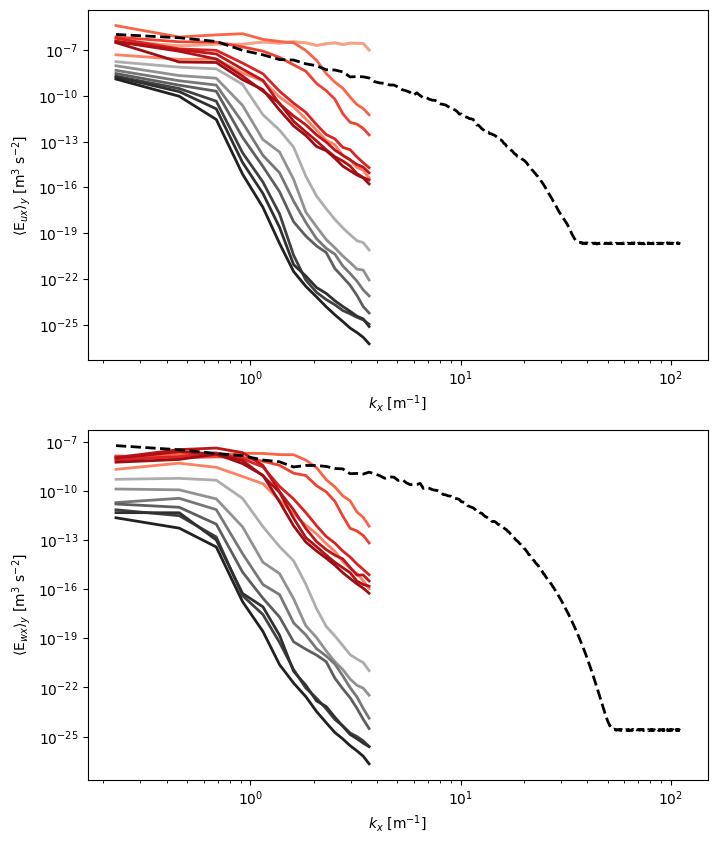

In [4]:
timesteps_all=[[1386000]]

for ivar in range(len(var_all)):
    var=var_all[ivar]
    for iRe in range(len(Re_all)):
        Re=Re_all[iRe]
        path='/glade/u/home/adac/work/DNSdata/DNS_SBL_L320/'+Re
        timesteps=timesteps_all[iRe]
        nt=len(timesteps)

        for it,timestep in enumerate(timesteps):
            
            ds = xr.open_dataset(path+var+str(timestep)+'.nc',decode_times=0)
            print(ds)
           
            try:
              x=ds['xh'].values
            except:
              x=ds['x'].values
            nx=len(x)
            dx=np.mean(np.diff(x))

            try:
              y=ds['yh'].values
            except:
              y=ds['y'].values
            ny=len(y)

            try:
              z=ds['zh'].values
              hgts=hgts_h
            except:
              z=ds['z'].values
              hgts=hgts_c

            for ihgt,hgt in enumerate(hgts):
                
                k=(np.abs(z - hgt)).argmin()


                w=ds[var][0, k].values
                
                kxy = 2*np.pi*np.fft.rfftfreq(nx,d=dx)
                dk=kxy[1] # should be smallest wavenumber 2pi/(length_fline*dx)
                lenf=len(kxy)# length_fline/2+1
                sp = np.empty([ny,lenf])
                #sp = np.empty([nF,avgt,length_yline,lenf])
                #sP = np.empty([nF,lenf])
                print('Plot spectra plot for time '+str(timestep)+' at height '+str(z[k]))
                #Can make use of below loop if we want to loop through files but b/c the NBL is developping probably shouldn't
                #  for F in range(nF): # File index
                #    for i in range(avgt): # Time index
                #      for ix in range(length_fline): # x (lon) index
                #        for iy in range(length_yline): # y (lat) index
                #          Wall[F,i,ix,iy]=fsall[F][nstart+i].variables['W'][nsall[F][nstart+i]][k][(Y1+iy),(X1+ix)]
                           # Wdiag = np.array([fsall[F][nstart+i].variables['W'][nsall[F][nstart+i]][k][Y1-count,X1] for count in range(length_fline)])
                            #normalize spectra values
                #    for i in range(avgt):
                #      for iy in range(length_yline):
    
                #Different detrending options
                #N = np.linspace(0,Wall[F,i,0,iy]-Wall[F,i,-1,iy],Wall[F,i,:,iy].shape[0])
                #N = -np.mean(Wall[F,i,:,iy])
                N=0 # detrending not necessary b/c periodic BCs
                for j in range(ny):
                    sp_tmp = np.fft.rfft(w[j,:]+N)
                    # sp_tmp = np.fft.rfft(w[k,:,j]+N)
                    sp[j,:] = (np.power(sp_tmp.real,2) + np.power(sp_tmp.imag,2))*dx/2.0/np.pi/nx #missing factor of two from Durran paper neccesary for the parseval's thereom to work
                    # sp[j,-1] = sp[j,-1]/2.0 #Nyquist frequency (last entry by order of reqdiag) is unique for even pts FFT, so has twice the power
                    # sp[j,0] = sp[j,0]/2.0 # Calculating the 0 wavenumber, won't be plotted on a log log but just to check the assumption of zero power at zero wavenumber for different detrending methods
                    #Confirming calcs throuch Parseval's theorem
                    #wsqr=np.sum(np.power(w[k,j],2))/nx/2.0
                    #wsqr_fft=np.sum(sp[j])*dk
                    #print(wsqr,wsqr_fft)
    
                sP = np.mean(sp,axis=0)
                power = abs(sP)
    
                axs[ivar].loglog(kxy[1:],power[1:],'k--',linewidth=2,label='DNS          0.5 h')

fig

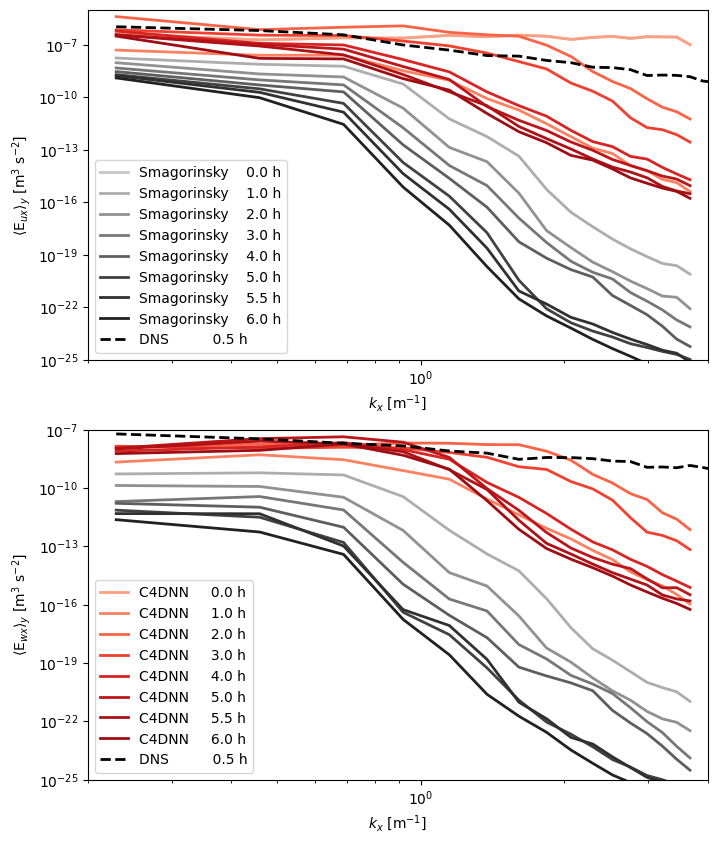

In [5]:
# axs[0].legend(ncol=3)
for i in range(len(axs)):
    axs[i].set_xlim([2e-1,4e0])
axs[0].set_ylim([1e-25,1e-5])
axs[1].set_ylim([1e-25,1e-7])

handles,labels=axs[0].get_legend_handles_labels()
nLabel=len(labels)
axs[0].legend(ncol=1,handles=handles[:int(nLabel/2)] + handles[-1:],labels=labels[:int(nLabel/2)] + labels[-1:])
axs[1].legend(ncol=1,handles=handles[int(nLabel/2):],labels=labels[int(nLabel/2):])

fig

In [6]:
# save=True
if save:
    plt.figure(fig)
    fmts=["png","eps"]
    for fmt in fmts:
        plt.savefig("Spectra_longTimeLastDNS."+fmt, format=fmt)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
